<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/March2026/3marchResnet18BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ======================================================
# 🔹 IMPORTS
# ======================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit

# ======================================================
# 🔹 DEVICE
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# 🔹 TRANSFORMS
# ======================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ======================================================
# 🔹 LOAD FULL DATASET
# ======================================================
dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/ImagesIngrouped",  # your train folder
    transform=train_transform
)

print("Total dataset size:", len(dataset))

# ======================================================
# 🔹 STRATIFIED 70:30 SPLIT
# ======================================================
labels = [dataset[i][1] for i in range(len(dataset))]

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# IMPORTANT: set validation transform separately
val_dataset.dataset.transform = val_transform

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

# ======================================================
# 🔹 DATALOADERS
# ======================================================
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

import torchvision.models as models
import torch.nn as nn

num_classes = len(dataset.classes)

model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)
# ======================================================
# 🔹 LOSS & OPTIMIZER
# ======================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)
# ======================================================
# 🔹 TRAINING SETTINGS
# ======================================================
epochs = 20
best_val_acc = 0.0
patience = 5
patience_counter = 0

# ======================================================
# 🔹 TRAINING LOOP
# ======================================================
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = 100.0 * train_correct / train_total

    # -------- VALIDATION --------
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100.0 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")

    # -------- EARLY STOPPING --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/Models/3marchResnet18.pth")
        print("✅ Best model saved")
    else:
        patience_counter += 1
        print(f"⏳ No improvement ({patience_counter}/{patience})")

    if patience_counter >= patience:
        print("🛑 Early stopping triggered")
        break

print("Training complete")
print("Best validation accuracy:", best_val_acc)

Total dataset size: 625
Train size: 437
Validation size: 188


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


Epoch [1/20] Train Acc: 34.10% | Val Acc: 53.19%
✅ Best model saved
Epoch [2/20] Train Acc: 51.26% | Val Acc: 51.06%
⏳ No improvement (1/5)
Epoch [3/20] Train Acc: 56.52% | Val Acc: 59.04%
✅ Best model saved
Epoch [4/20] Train Acc: 65.22% | Val Acc: 60.64%
✅ Best model saved
Epoch [5/20] Train Acc: 65.68% | Val Acc: 57.98%
⏳ No improvement (1/5)
Epoch [6/20] Train Acc: 64.76% | Val Acc: 56.91%
⏳ No improvement (2/5)
Epoch [7/20] Train Acc: 67.96% | Val Acc: 64.36%
✅ Best model saved
Epoch [8/20] Train Acc: 72.54% | Val Acc: 62.77%
⏳ No improvement (1/5)
Epoch [9/20] Train Acc: 72.54% | Val Acc: 55.85%
⏳ No improvement (2/5)
Epoch [10/20] Train Acc: 71.62% | Val Acc: 61.17%
⏳ No improvement (3/5)
Epoch [11/20] Train Acc: 70.25% | Val Acc: 59.04%
⏳ No improvement (4/5)
Epoch [12/20] Train Acc: 73.00% | Val Acc: 59.04%
⏳ No improvement (5/5)
🛑 Early stopping triggered
Training complete
Best validation accuracy: 64.36170212765957


In [4]:
model.load_state_dict(torch.load("/content/drive/MyDrive/Models/3marchResnet18.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
data_loader = val_loader

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

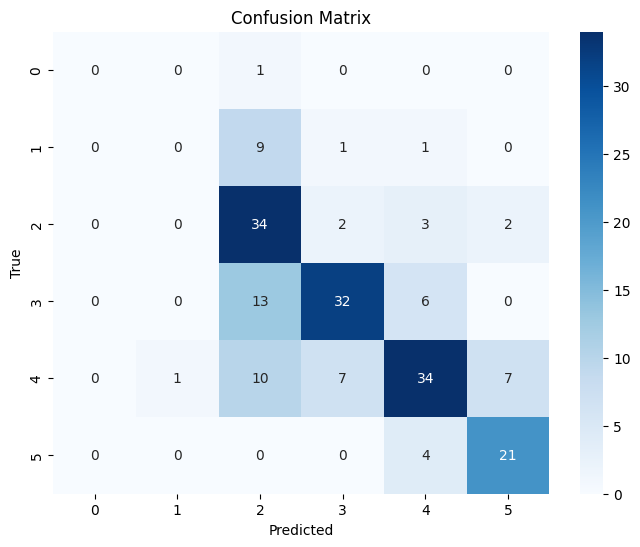

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(f"Class {dataset.classes[i]} Accuracy: {acc*100:.2f}%")

Class 0 Accuracy: 0.00%
Class 1 Accuracy: 0.00%
Class 2 Accuracy: 82.93%
Class 3 Accuracy: 62.75%
Class 4 Accuracy: 57.63%
Class 5 Accuracy: 84.00%


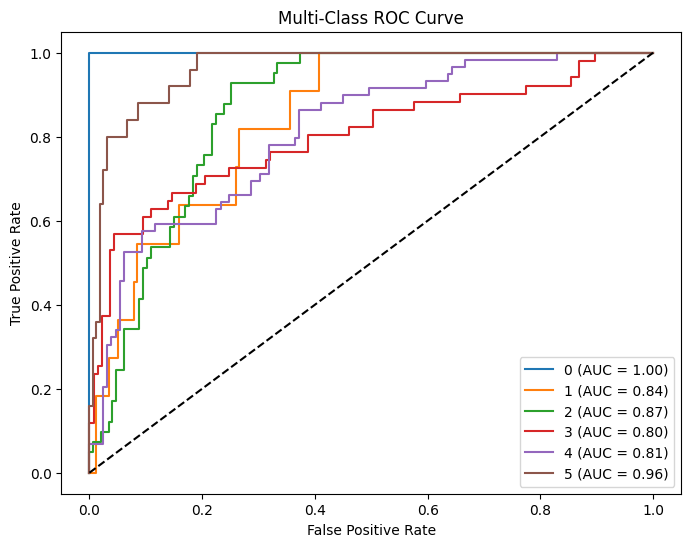

In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

num_classes = len(dataset.classes)

labels_onehot = label_binarize(all_labels, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


In [11]:
print(classification_report(all_labels, all_preds,
                            target_names=dataset.classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        11
           2       0.51      0.83      0.63        41
           3       0.76      0.63      0.69        51
           4       0.71      0.58      0.64        59
           5       0.70      0.84      0.76        25

    accuracy                           0.64       188
   macro avg       0.45      0.48      0.45       188
weighted avg       0.63      0.64      0.62       188



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
